# 多轮对话消息流处理
和chunk用法类似，展示一下，如果子图里面嵌套使用了大模型，这个时候大模型信息，也可以正常流式输出，和前面父节点一个字一个字跑出来一样的，是逐token输出的


 ============================== -> 第一次运行结果 <- ==============================
(('call_subgraph',), 'messages', (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--01a0b8b9-1896-7bd1-b8bd-98ee249bc59b', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'subgraph_stream_test', 'langgraph_step': 1, 'langgraph_node': 'llm_mode', 'langgraph_triggers': ('branch:to:llm_mode',), 'langgraph_path': ('__pregel_pull', 'llm_mode'), 'langgraph_checkpoint_ns': 'call_subgraph|llm_mode:0cea300a-c2e1-019d-011c-2d8aad2d36ae', 'checkpoint_ns': 'call_subgraph:e7209bfa-6fab-0414-dd3c-e6b8e8ad548b', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-v4-flash', 'ls_model_type': 'chat', 'ls_temperature': None}))
(('call_subgraph',), 'messages', (AIMessageChunk(content='这句', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--01a0b8b9-1896-7bd1-b8bd-98ee249bc59b', tool_calls=[], invalid_tool_ca

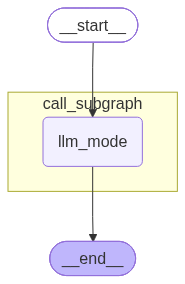

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 构建子图
class SubgraphState(MessagesState):
    system_prompt: SystemMessage

def llm_mode(state: SubgraphState) -> SubgraphState:
    system_prompt = state["system_prompt"]
    messages = state["messages"]

    response = model.invoke([system_prompt] + messages)
    return {
        "messages": [response]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("llm_mode", llm_mode)
builder.add_edge(START, "llm_mode")
builder.add_edge("llm_mode", END)

subgraph = builder.compile(checkpointer=True) # 开启per-thread，会有持久记忆

# 构建父图
class ParentState(TypedDict):
    user_input: str
    assistant_response: str

def call_subgraph(state: ParentState) -> ParentState:
    user_input = state["user_input"]

    response = subgraph.invoke(
        {
            "system_prompt": SystemMessage("你是个善解人意的助手"),
            "messages": [HumanMessage(user_input)]
        }
    )

    assistant_response = response["messages"][-1].content

    return {
        "assistant_response": assistant_response
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "subgraph_stream_test"}}

print("\n", "=" * 30, "-> 第一次运行结果 <-", "=" * 30)
# chunk 形如
# (('call_subgraph',), 'messages', (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019efd65-c54e-7012-912e-29ff4f84328e', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'subgraph_stream_test', 'langgraph_step': 1, 'langgraph_node': 'llm_mode', 'langgraph_triggers': ('branch:to:llm_mode',), 'langgraph_path': ('__pregel_pull', 'llm_mode'), 'langgraph_checkpoint_ns': 'call_subgraph|llm_mode:55577c3e-22da-877a-c77b-f16bdbcd2c6c', 'checkpoint_ns': 'call_subgraph:9c469391-f094-1c1b-c5d7-6578f1603151', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-v4-flash', 'ls_model_type': 'chat', 'ls_temperature': None}))
for chunk in parent_graph.stream( # 对父节点取chunk
    {
        "user_input": "花儿为什么这样红？"
    },
    config=config,
    subgraphs=True,  # 一定要有，不然不打印内容
    stream_mode=["messages"] # 看到大模型流式输出的内容
):
    print(chunk) # 输出全部内容
    # print(chunk[2][0].content, end="", flush=True) # 只想看最终的结果

print("\n", "=" * 30, "-> 第二次运行结果 <-", "=" * 30)
for chunk in parent_graph.stream(
    {
        "user_input": "刚才我们聊了什么？"
    },
    config=config,
    subgraphs=True,
    stream_mode=["messages"]
):
    print(chunk[2][0].content, end="", flush=True) # 只打印内容

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)

知道可以正常使用就行
